Airbnb listings in New York, New York

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = pd.read_csv('listings.csv')

In [2]:
#pull columns we care abt
ndf = data[['listing_url','hosts_time_as_host_years', 'hosts_time_as_host_months'
            , 'neighbourhood_cleansed', 'neighbourhood_group_cleansed'
            ,'accommodates', 'bathrooms', 'bedrooms', 'price', 'estimated_revenue_l365d', 'review_scores_rating', 'reviews_per_month']].copy()

#change host time to total yrs
ndf['hosts_time_as_host_years'] = ndf['hosts_time_as_host_years'] * 12 + ndf['hosts_time_as_host_months']
ndf = ndf.drop(columns=['hosts_time_as_host_months'], axis=1)
ndf = ndf.rename(columns={'hosts_time_as_host_years' : 'months_as_host',
                            'neighbourhood_cleansed' : 'neighbourhood',
                            'neighbourhood_group_cleansed' : 'neighbourhood_group',
                            'estimated_revenue_l365d' : 'revenue_per_yr',
                            'review_scores_rating' : 'rating'})

#Remove airbnbs with 0 revenue and reviews_per_month
ndf = ndf[(ndf['revenue_per_yr'] != 0)]
ndf = ndf[(ndf['reviews_per_month'] != 0)]

#dropped listings with no accommdation listing
ndf = ndf.dropna(subset=['accommodates', 'price', 'months_as_host'])

#Dropped the $ sign and converted column to float values
ndf['price'] = ndf['price'].str.replace(r'[^\d.]', '', regex=True) # \"^/d means not
ndf['price'] = pd.to_numeric(ndf['price']).astype(float)

#fill in na bedrooms and bathrooms with the median number found in accomdations
ndf['bedrooms'] = ndf['bedrooms'].fillna(ndf.groupby('accommodates')['bedrooms'].transform('median'))
ndf['bathrooms'] = ndf['bathrooms'].fillna(ndf.groupby('accommodates')['bathrooms'].transform('median'))

#Change empty price values and revenue_per_yr to median based on neighbourgood
ndf['price'] = ndf['price'].fillna(ndf.groupby('neighbourhood')['price'].transform('median'))
ndf['revenue_per_yr'] = ndf['revenue_per_yr'].fillna(ndf.groupby('neighbourhood')['revenue_per_yr'].transform('median'))

ndf.head()

,listing_url,months_as_host,neighbourhood,neighbourhood_group,accommodates,bathrooms,bedrooms,price,revenue_per_yr,rating,reviews_per_month
0,https://www.airbnb.com/rooms/2539,185.0,Kensington,Brooklyn,2,1.0,1.0,113.97,6838.0,4.80,0.08
1,https://www.airbnb.com/rooms/6848,185.0,Williamsburg,Brooklyn,3,1.0,2.0,117.27,21109.0,4.60,0.95
2,https://www.airbnb.com/rooms/6872,185.0,East Harlem,Manhattan,1,1.0,1.0,80.06,4804.0,5.00,0.04
3,https://www.airbnb.com/rooms/6990,185.0,East Harlem,Manhattan,1,1.0,1.0,77.17,9260.0,4.88,1.24
4,https://www.airbnb.com/rooms/7097,185.0,Fort Greene,Brooklyn,2,1.0,1.0,202.47,51630.0,4.89,2.12


In [3]:
#finding null values
ndf.isnull().any()

listing_url            False
months_as_host         False
neighbourhood          False
neighbourhood_group    False
accommodates           False
bathrooms              False
bedrooms               False
price                  False
revenue_per_yr         False
rating                 False
reviews_per_month      False
dtype: bool

In [4]:
ndf.max()

listing_url            https://www.airbnb.com/rooms/999964466102080007
months_as_host                                                   185.0
neighbourhood                                                 Woodside
neighbourhood_group                                      Staten Island
accommodates                                                        16
bathrooms                                                          7.0
bedrooms                                                           9.0
price                                                          7014.67
revenue_per_yr                                               1788741.0
rating                                                             5.0
reviews_per_month                                               115.63
dtype: object

Mean price in relation to neighbourhood

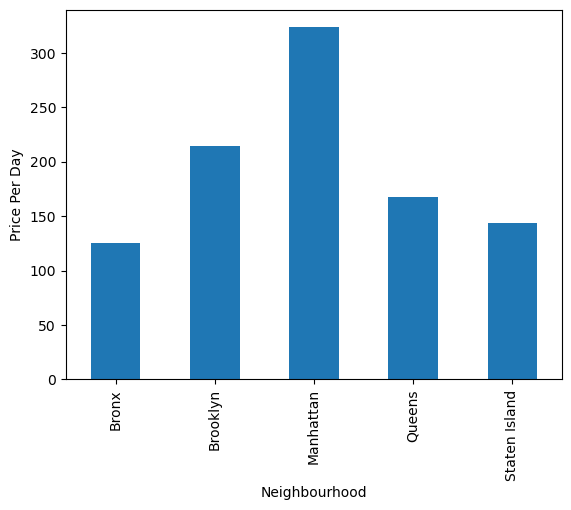

In [5]:
ndf['neighbourhood_group'].unique()
mean_neighbour_group = ndf.groupby('neighbourhood_group')['price'].mean()

mean_neighbour_group.plot(x='neighbourhood_group', y='price', kind='bar')
plt.xlabel('Neighbourhood')
plt.ylabel('Price Per Day')

plt.show()


Neighbourhood and price

In [6]:
splt = ndf[['neighbourhood_group', 'neighbourhood', 'price']]
splt = splt.set_index(['neighbourhood_group', 'neighbourhood'])
splt = splt.sort_index()

splt.head()

price
neighbourhood_group neighbourhood        
Bronx               Allerton        77.29
                    Allerton       101.40
                    Allerton        54.57
                    Allerton       120.00
                    Allerton       165.50

Price, Accomdates, Reviews Per Month, and Neighbourhood to predict Revenue per year (ridge regression)

In [7]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

#Load Data and drop nan values
df = ndf[['price', 'reviews_per_month', 'revenue_per_yr', 'accommodates', 'neighbourhood']]
    
#Turn neighborhood group into binary
df = pd.get_dummies(df, columns=['neighbourhood'], drop_first=True, dtype=int)

#Drop price outliers
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
df = df[(df['price'] >= lower) & (df['price'] <= upper)]

X = df.drop(columns=['revenue_per_yr'])
y = df['revenue_per_yr']

#Training and Testing
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size=0.2)
scaler = StandardScaler()
Xtrainscaled = scaler.fit_transform(Xtrain)
Xtestscaled = scaler.transform(Xtest)

#Load model
model = Ridge(alpha=93.0)
model.fit(Xtrainscaled, ytrain)

# Calculate the R² score on test data
r2_accuracy = model.score(Xtestscaled, ytest)
print(f"R² Score: {r2_accuracy}")

R² Score: 0.5335053714051854


In [8]:
from sklearn.linear_model import RidgeCV
alphas = np.logspace(-3, 3, 100)
    
optimal = RidgeCV(alphas=alphas, cv=5)
optimal.fit(Xtrainscaled, ytrain)

print(f"Best Alpha: {optimal.alpha_}")

Best Alpha: 61.35907273413176


Trying to determine price from rooms and ammenties

In [75]:
#Turn amenities into binary
import json
from sklearn.preprocessing import MultiLabelBinarizer

#Parse JSON list
def parse_amenities(x):
    if pd.isna(x):
        return []
    try:
        return json.loads(x)
    except (json.JSONDecodeError, TypeError):
        return []

df["amenities_clean"] = data['amenities'].apply(parse_amenities)

#Create columns for each amenity
mlb = MultiLabelBinarizer()
amenities_df = pd.DataFrame(mlb.fit_transform(df["amenities_clean"]), 
                            columns=[f"amenity_{col}" for col in mlb.classes_],
                            index=df.index,)

#For dropping original columns later
dropcols = []

#Group columns with similar keywords together
keywords = {"shampoo" : ["shampoo"],
            "conditioner" : ["conditioner"],
            "body soap" : ["body soap"],
            "oven" : ["oven"],
            "refrigerator" : ["refrigerator", "freezer"],
            "tv" : ["tv"],
            "basic cooking" : ["stove", "cooking basics", "dishes", "silverware", "hot water"],
            "sound system" : ["sound system"],
            "wifi" : ["wifi", "ethernet"],
            "washer" : ["washer"],
            "dryer" : ["dryer"],
            "grill" : ["grill", "barbecue"],
            "baby monitor" : ["baby monitor"],
            "beach" : ["beach"],
            "baby" : ["baby", "crib"],
            "backyard" : ["backyard"],
            "breakfast" : ["breakfast"],
            "kid seat" : ["booster seat", "high chair"],
            "cooling n heating" : ["air conditioning", "heating", "ac"],
            "cheap entertainment" : ["board games", "book"],
            "children amenities" : ["children"],
            "table" : ["table"],
            "storage" : ["clothing storage", "storage", "ceiling fan"],
            "coffee" : ["coffee"],
            "ev charger" : ["ev charger"],
            "luxury" : ["arcade", "bowling", "climbing wall", "batting cage", "game console", 
                        "hockey rink", "bar", "indoor pool", "hot tub"],
            "gym" : ["exercise", "weights", "gym"],
            "safety devices" : ["fire", "first aid", "carbon monoxide", "security cameras"],
            "parking" : ["free parking", "free carport", "free driveway", 
                         "free street parking", "free residential"],
            "view" : ["view"],
            "house keeping" : ["housekeeping"]}

for newcol, keyword in keywords.items():
    matchcols = [col for col in amenities_df.columns
        if any(kw in col.lower() for kw in keyword)]

    amenities_df[newcol] = amenities_df[matchcols].any(axis=1).astype(int)

    dropcols.extend(matchcols)
amenities_df = amenities_df.drop(columns=list(set(dropcols)))

amenities_df.head()

,amenity_Baking sheet,amenity_Bathtub,amenity_Bed linens,amenity_Bidet,amenity_Bikes,amenity_Blender,amenity_Boat slip,amenity_Bread maker,amenity_Building staff,amenity_Cleaning available during stay,...,table,storage,coffee,ev charger,luxury,gym,safety devices,parking,view,house keeping
0,0,1,1,0,1,1,0,0,0,1,...,1,1,1,0,0,0,1,1,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,1,1,0,0,0,1,1,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,1,1,0,0,0,1,1,1,0


In [112]:
#amenities_df.columns.tolist()

Lasso regression on amenities_df and neighbourhood to predict price

In [113]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#load data
amenities_df['accommodates'] = ndf['accommodates']
amenities_df['neighbourhood'] = ndf['neighbourhood']
amenities_df['price'] = data['price']
amenities_df['price'] = amenities_df['price'].str.replace(r'[^\d.]', '', regex=True) # \"^/d means not
amenities_df['price'] = pd.to_numeric(amenities_df['price']).astype(float)
amenities_df = pd.get_dummies(amenities_df, columns=['neighbourhood'], drop_first=True, dtype=int)
amenities_df['revenue_per_yr'] = ndf['revenue_per_yr']
amenities_df['reviews_per_month'] = ndf['reviews_per_month']

#Drop price outliers
q1 = amenities_df['price'].quantile(0.25)
q3 = amenities_df['price'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
amenities_df = amenities_df[(amenities_df['price'] >= lower) & (amenities_df['price'] <= upper)]

amenities_df = amenities_df[(amenities_df['revenue_per_yr'] != 0)]
amenities_df = amenities_df[(amenities_df['reviews_per_month'] != 0)]

X = amenities_df.drop(columns=['price', 'revenue_per_yr', 'reviews_per_month'])
y = amenities_df['price']

#train data
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size=0.2)
scaler = StandardScaler()
Xtrainscaled = scaler.fit_transform(Xtrain)
Xtestscaled = scaler.transform(Xtest)

#Load model
model = Lasso(alpha=1)
model.fit(Xtrainscaled, ytrain)

# Calculate the R² score on test data
r2_accuracy = model.score(Xtestscaled, ytest)
print(f"R² Score: {r2_accuracy}")

R² Score: 0.39019153001015683


In [114]:
from sklearn.linear_model import LassoCV
alphas = np.logspace(-3, 3, 100)
    
optimal = LassoCV(alphas=alphas, cv=5)
optimal.fit(Xtrainscaled, ytrain)

print(f"Best Alpha: {optimal.alpha_}")

Best Alpha: 2.1544346900318843
